# 15 - Feature Follow-ups Model

Tests `07_descriptive_analysis.ipynb`'s three remaining deferred
feature-engineering findings (the fourth, distance-from-center, was
already tested in isolation by `13_distance_feature_test.ipynb` and found
to be exactly redundant with `station_id`) on top of
`14_random_forest_model.ipynb`'s current best model
(`RandomForestRegressor`, MAE 27.34 / RMSE 54.13 overall):

1. **Bucketed precipitation** (`precipitation_bucket`): notebook 07 found
   raw `weather_precipitation_mm` has a near-zero linear correlation with
   traffic (r ~= -0.03), but a real threshold effect once bucketed (near-
   zero until it actually rains, then a step down). Uses the exact same
   bin edges notebook 07 defined
   (`analysis.descriptive.DEFAULT_PRECIPITATION_BINS`/`_LABELS`).
2. **Explicit hour x day-of-week interaction** (`hour_dow`): a single
   combined categorical for the (hour, day_of_week) pair, testing whether
   making the interaction explicit measurably helps a tree model over the
   two separate columns it can already split on independently - or is
   redundant, the way distance-from-center turned out to be for
   `station_id` in notebook 13.
3. **Per-station weekend/weekday ratio** (`weekend_weekday_ratio`): a
   static per-station `mean(weekend total_count) / mean(weekday
   total_count)`, computed from **training-period rows only** (see
   section 3 for why: computing it from the full dataset, including the
   test period, would leak future average-traffic information into a
   feature applied to training rows too) and then broadcast onto both
   train and test rows as a static per-station value.

All three are implemented as pure functions in
`src/muenster_bike_forecast/modeling/feature_followups.py` (unit-tested
in `tests/test_feature_followups.py`), added on top of `14`'s identical
base feature set and lag/rolling features, with the identical
`RandomForestRegressor` hyperparameters (`n_estimators=60, max_depth=14,
min_samples_leaf=10, max_samples=0.15`) so any change is attributable to
the new features, not a confounded hyperparameter change. Effect is
measured two ways: leave-one-feature-out ablation (retrain without one of
the three, compare MAE/RMSE) and permutation importance within the
combined model - both reported honestly, including if the answer is "no
effect", per this project's convention (see notebook 13's distance-
feature null result).

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Make `src/` importable regardless of whether this notebook is run from
# `notebooks/` (the normal case) or the project root.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.modeling.feature_followups import (
    add_hour_dow_interaction,
    add_precipitation_bucket,
    add_weekend_weekday_ratio_feature,
    compute_weekend_weekday_ratio,
)
from muenster_bike_forecast.modeling.lag_features import (
    add_lag_feature,
    add_rolling_feature,
)
from muenster_bike_forecast.modeling.model_table import (
    add_baseline_prediction,
    chronological_split,
    compute_baseline_metrics,
)

MODEL_TABLE_PATH = PROJECT_ROOT / "data" / "raw" / "model_table" / "model_table.csv"
TEST_PERIOD = pd.Timedelta(weeks=8)

RANDOM_STATE = 0

# Notebook 14's actual result (same feature set, same holdout, same RF
# hyperparameters) - reused as the "no new features" reference point
# rather than retrained here, the same convention notebook 14 itself used
# for the GBM/LightGBM/MLP reference numbers.
RF_BASELINE_OVERALL = pd.DataFrame(
    [{"group": "overall", "mae": 27.343144, "rmse": 54.130155, "n_rows": 106043}]
)

## 1. Load the assembled feature table

Identical source as notebook 14: `data/raw/model_table/model_table.csv`,
one row per `(station_id, datetime)` at 15-minute resolution, 23
stations, with `total_count`, the 24h-ahead `target_total_count`,
calendar features, and current weather already joined.

In [2]:
full_df = pd.read_csv(MODEL_TABLE_PATH, parse_dates=["datetime"])
full_df = full_df.sort_values(["station_id", "datetime"]).reset_index(drop=True)
print(f"Loaded {len(full_df):,} rows x {full_df.shape[1]} columns from {MODEL_TABLE_PATH}")
full_df.head()

Loaded 2,337,596 rows x 20 columns from C:\Users\FloKI\Documents\Daten\muenster-bike-traffic-forecast\.claude\worktrees\agent-a5a2cef4067cf221f\data\raw\model_table\model_table.csv


,station_id,datetime,weather_quality_level,weather_air_temperature_c,weather_relative_humidity_pct,weather_precipitation_quality_level,weather_precipitation_mm,weather_precipitation_indicator,weather_precipitation_form,weather_wind_quality_level,weather_wind_speed_ms,weather_wind_direction_deg,total_count,target_total_count,hour,day_of_week,month,is_public_holiday,is_school_holiday,is_lecture_period
0,100020113,2023-01-01 00:00:00,3.0,16.6,51.0,3.0,0.0,0.0,0.0,10.0,9.0,210.0,2.0,6.0,0,6,1,True,True,True
1,100020113,2023-01-01 00:15:00,3.0,16.6,51.0,3.0,0.0,0.0,0.0,10.0,9.0,210.0,30.0,6.0,0,6,1,True,True,True
2,100020113,2023-01-01 00:30:00,3.0,16.6,51.0,3.0,0.0,0.0,0.0,10.0,9.0,210.0,32.0,10.0,0,6,1,True,True,True
3,100020113,2023-01-01 00:45:00,3.0,16.6,51.0,3.0,0.0,0.0,0.0,10.0,9.0,210.0,42.0,4.0,0,6,1,True,True,True
4,100020113,2023-01-01 01:00:00,3.0,16.7,50.0,3.0,0.0,0.0,0.0,10.0,9.4,210.0,70.0,0.0,1,6,1,True,True,True


## 2. Add lag/rolling history features

Identical spec to notebook 14: `lag_1h`/`lag_1d`/`lag_1w` (exact-timestamp
lookups of `total_count`) and `rolling_mean_2h`/`rolling_mean_24h`
(trailing time-windowed means, `closed="left"`), computed strictly from
data at or before each row's own timestamp.

In [3]:
LAG_SPECS = {
    "lag_1h": pd.Timedelta(hours=1),
    "lag_1d": pd.Timedelta(days=1),
    "lag_1w": pd.Timedelta(weeks=1),
}
ROLLING_SPECS = {
    "rolling_mean_2h": pd.Timedelta(hours=2),
    "rolling_mean_24h": pd.Timedelta(hours=24),
}

for feature_col, lag in LAG_SPECS.items():
    full_df = add_lag_feature(full_df, lag=lag, feature_col=feature_col)

for feature_col, window in ROLLING_SPECS.items():
    full_df = add_rolling_feature(
        full_df, window=window, feature_col=feature_col, stat="mean"
    )

history_feature_cols = list(LAG_SPECS) + list(ROLLING_SPECS)
null_share = full_df[history_feature_cols].isna().mean().mul(100).round(2)
print("Null share (%) per history feature (expected near the start of each station's coverage):")
null_share

Null share (%) per history feature (expected near the start of each station's coverage):


lag_1h              0.15
lag_1d              3.07
lag_1w              4.08
rolling_mean_2h     0.03
rolling_mean_24h    0.02
dtype: float64

## 3. Chronological train/test split

Same global 8-week cutoff as notebook 14 (`chronological_split`): a
single cutoff derived from `max(datetime)` across *all* stations, applied
uniformly, so time order is respected and no station's "future" leaks
relative to another's.

This split happens **before** the weekend/weekday ratio is computed
(section 4 below) specifically so that ratio can be computed from
`train_labeled` only - the leakage guard the task requires.

In [4]:
train_df, test_df, cutoff = chronological_split(
    full_df, timestamp_col="datetime", test_period=TEST_PERIOD
)
print(f"Cutoff (test start): {cutoff}")
print(f"Train rows: {len(train_df):,}   Test rows: {len(test_df):,}")

# Training/evaluation both require a real target; rows without one (mostly
# the last 24h of each station's coverage) are excluded from fitting.
train_labeled = train_df.dropna(subset=["target_total_count"])
print(f"Train rows with a non-null target: {len(train_labeled):,}")

Cutoff (test start): 2026-05-11 04:45:00
Train rows: 2,225,596   Test rows: 112,000


Train rows with a non-null target: 2,159,884


## 4. Add the three follow-up features

- `precipitation_bucket` and `hour_dow` are row-level transforms (no
  leakage risk - each row's bucket/interaction category depends only on
  its own `weather_precipitation_mm`/`hour`/`day_of_week`), so they're
  added directly to both `train_labeled` and `test_df` independently.
- `weekend_weekday_ratio` is different: it's a per-station *aggregate* of
  `total_count` history. `compute_weekend_weekday_ratio` is called on
  **`train_labeled` only** (rows strictly before the chronological
  cutoff from section 3) - never on `test_df` or the full `full_df` -
  then `add_weekend_weekday_ratio_feature` broadcasts that single static
  per-station table onto *both* `train_labeled` and `test_df`. This is
  the leakage guard the task requires: if the ratio were computed from
  the full dataset (including the test period), future average-traffic
  information would leak into a feature applied to training rows too.

In [5]:
# Row-level features: safe to add to train and test independently.
train_labeled = add_precipitation_bucket(train_labeled)
train_labeled = add_hour_dow_interaction(train_labeled)
test_df = add_precipitation_bucket(test_df)
test_df = add_hour_dow_interaction(test_df)

# Per-station aggregate feature: computed from train_labeled ONLY, then
# broadcast onto both train and test. See markdown above for why.
weekend_weekday_ratio_table = compute_weekend_weekday_ratio(train_labeled)
train_labeled = add_weekend_weekday_ratio_feature(
    train_labeled, weekend_weekday_ratio_table
)
test_df = add_weekend_weekday_ratio_feature(test_df, weekend_weekday_ratio_table)

print(
    f"precipitation_bucket categories: {train_labeled['precipitation_bucket'].cat.categories.tolist()}"
)
print(f"hour_dow: {train_labeled['hour_dow'].nunique()} distinct (hour, day_of_week) pairs")
print("\nPer-station weekend/weekday ratio (train-period only), sorted:")
weekend_weekday_ratio_table.sort_values("weekend_weekday_ratio", ascending=False)

precipitation_bucket categories: ['dry (0-0.1mm)', 'light (0.1-1mm)', 'moderate (1-5mm)', 'heavy (> 5mm)']


hour_dow: 168 distinct (hour, day_of_week) pairs

Per-station weekend/weekday ratio (train-period only), sorted:


,station_id,weekend_weekday_ratio
19,300037936,1.471777
11,300037544,0.966297
9,100053305,0.859934
2,100031300,0.649668
4,100034980,0.643080
0,100020113,0.637167
13,300037925,0.636892
16,300037931,0.633780
22,300039331,0.627171
14,300037926,0.612530


## 5. Feature-set variants: combined + leave-one-out ablations

Same preprocessing choice as notebook 14 (median imputation for numeric
features, one-hot encoding for categoricals, no scaling - tree splits are
scale-invariant) and the identical `RandomForestRegressor` hyperparameters
(`n_estimators=60, max_depth=14, min_samples_leaf=10, max_samples=0.15,
n_jobs=-1, random_state=0`).

Four variants are actually trained here (the fifth, "no new features",
is notebook 14's own result, reused as `RF_BASELINE_OVERALL` rather than
retrained - identical code path, so retraining it would just reproduce
the same number):

- **`combined`**: notebook 14's base feature set plus all three new
  features (`precipitation_bucket`, `hour_dow` as categoricals;
  `weekend_weekday_ratio` as numeric).
- **`minus_precipitation_bucket`**: `combined` without
  `precipitation_bucket`.
- **`minus_hour_dow`**: `combined` without `hour_dow`.
- **`minus_weekend_ratio`**: `combined` without `weekend_weekday_ratio`.

Comparing each `minus_*` variant back to `combined` isolates that one
feature's individual marginal effect (in the presence of the other two),
rather than only measuring the three features' combined effect.

In [6]:
BASE_CATEGORICAL = [
    "station_id",
    "hour",
    "day_of_week",
    "month",
    "is_public_holiday",
    "is_school_holiday",
    "is_lecture_period",
]
BASE_NUMERIC = [
    "total_count",
    "weather_air_temperature_c",
    "weather_relative_humidity_pct",
    "weather_precipitation_mm",
    "weather_wind_speed_ms",
    *history_feature_cols,
]

NEW_CATEGORICAL = ["precipitation_bucket", "hour_dow"]
NEW_NUMERIC = ["weekend_weekday_ratio"]

VARIANT_FEATURES: dict[str, tuple[list[str], list[str]]] = {
    "combined": (
        BASE_NUMERIC + NEW_NUMERIC,
        BASE_CATEGORICAL + NEW_CATEGORICAL,
    ),
    "minus_precipitation_bucket": (
        BASE_NUMERIC + NEW_NUMERIC,
        BASE_CATEGORICAL + ["hour_dow"],
    ),
    "minus_hour_dow": (
        BASE_NUMERIC + NEW_NUMERIC,
        BASE_CATEGORICAL + ["precipitation_bucket"],
    ),
    "minus_weekend_ratio": (
        BASE_NUMERIC,
        BASE_CATEGORICAL + NEW_CATEGORICAL,
    ),
}


def _build_model(numeric_cols: list[str], categorical_cols: list[str]) -> Pipeline:
    """Builds the notebook-14-identical RF pipeline for a given feature set."""
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric_cols),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_cols,
            ),
        ]
    )
    return Pipeline(
        [
            ("preprocess", preprocessor),
            (
                "random_forest",
                RandomForestRegressor(
                    n_estimators=60,
                    max_depth=14,
                    min_samples_leaf=10,
                    max_samples=0.15,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


y_train = train_labeled["target_total_count"]
models: dict[str, Pipeline] = {}
fit_times: dict[str, float] = {}

for variant_name, (numeric_cols, categorical_cols) in VARIANT_FEATURES.items():
    feature_cols = numeric_cols + categorical_cols
    X_train = train_labeled[feature_cols]
    model = _build_model(numeric_cols, categorical_cols)
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_times[variant_name] = time.time() - t0
    models[variant_name] = model
    print(
        f"[{variant_name}] fit on {len(X_train):,} rows, {len(feature_cols)} raw "
        f"features in {fit_times[variant_name]:.1f}s."
    )

[combined] fit on 2,159,884 rows, 20 raw features in 654.0s.


[minus_precipitation_bucket] fit on 2,159,884 rows, 19 raw features in 672.4s.


[minus_hour_dow] fit on 2,159,884 rows, 19 raw features in 183.3s.


[minus_weekend_ratio] fit on 2,159,884 rows, 19 raw features in 316.5s.


## 6. Evaluate: overall MAE/RMSE, all variants vs. notebook 14's baseline

Same `compute_baseline_metrics` function used for every prediction column,
scored on the identical test rows, so MAE/RMSE stay directly comparable
to notebook 14's own result.

In [7]:
test_df = add_baseline_prediction(
    test_df, current_col="total_count", prediction_col="baseline_prediction"
)

for variant_name, (numeric_cols, categorical_cols) in VARIANT_FEATURES.items():
    feature_cols = numeric_cols + categorical_cols
    X_test = test_df[feature_cols]
    test_df[f"{variant_name}_prediction"] = models[variant_name].predict(X_test)

overall_rows = [
    compute_baseline_metrics(
        test_df, prediction_col="baseline_prediction", target_col="target_total_count"
    ).assign(model="seasonal_naive_baseline"),
    RF_BASELINE_OVERALL.assign(model="random_forest (notebook 14, no new features)"),
]
for variant_name in VARIANT_FEATURES:
    overall_rows.append(
        compute_baseline_metrics(
            test_df,
            prediction_col=f"{variant_name}_prediction",
            target_col="target_total_count",
        ).assign(model=f"random_forest ({variant_name})")
    )

overall_comparison = pd.concat(overall_rows, ignore_index=True)[
    ["model", "group", "mae", "rmse", "n_rows"]
]
overall_comparison

,model,group,mae,rmse,n_rows
0,seasonal_naive_baseline,overall,39.340343,77.252182,106043
1,"random_forest (notebook 14, no new features)",overall,27.343144,54.130155,106043
2,random_forest (combined),overall,27.616027,54.100053,106043
3,random_forest (minus_precipitation_bucket),overall,27.610493,54.090754,106043
4,random_forest (minus_hour_dow),overall,27.187247,53.908181,106043
5,random_forest (minus_weekend_ratio),overall,27.765615,54.317027,106043


## 7. Ablation: each feature's individual marginal effect

`combined` vs. each `minus_*` variant isolates one feature's own
contribution, holding the other two (and everything else) fixed. A
positive `mae_delta`/`rmse_delta` means removing that feature made the
model *worse* (i.e. the feature was helping); a negative delta means
removing it made the model *better* (i.e. the feature was hurting, or at
best doing nothing beyond adding noise for the trees to split on).

In [8]:
combined_overall = compute_baseline_metrics(
    test_df, prediction_col="combined_prediction", target_col="target_total_count"
).iloc[0]

ablation_rows = []
FEATURE_BY_ABLATION = {
    "minus_precipitation_bucket": "precipitation_bucket",
    "minus_hour_dow": "hour_dow",
    "minus_weekend_ratio": "weekend_weekday_ratio",
}
for ablation_variant, feature_name in FEATURE_BY_ABLATION.items():
    ablation_overall = compute_baseline_metrics(
        test_df,
        prediction_col=f"{ablation_variant}_prediction",
        target_col="target_total_count",
    ).iloc[0]
    ablation_rows.append(
        {
            "feature": feature_name,
            "combined_mae": combined_overall["mae"],
            "without_feature_mae": ablation_overall["mae"],
            "mae_delta": ablation_overall["mae"] - combined_overall["mae"],
            "combined_rmse": combined_overall["rmse"],
            "without_feature_rmse": ablation_overall["rmse"],
            "rmse_delta": ablation_overall["rmse"] - combined_overall["rmse"],
        }
    )

ablation_df = pd.DataFrame(ablation_rows)
ablation_df

,feature,combined_mae,without_feature_mae,mae_delta,combined_rmse,without_feature_rmse,rmse_delta
0,precipitation_bucket,27.616027,27.610493,-0.005534,54.100053,54.090754,-0.009300
1,hour_dow,27.616027,27.187247,-0.428779,54.100053,53.908181,-0.191873
2,weekend_weekday_ratio,27.616027,27.765615,0.149588,54.100053,54.317027,0.216974


## 8. Per-station comparison

Same per-station breakdown as notebook 14, `combined` vs. the notebook-14
baseline, with the two previously-flagged stations (`300037405`,
`300038855`) called out specifically -- notebook 14's own caveat (added
after cross-checking notebook 12) applies here too: notebook 12 found
`300038855`'s test window is ~90% gap-or-zero from a sensor outage, so any
model's score there (including this one) should not be over-interpreted
as a real skill improvement on that station.

In [9]:
# Notebook 14's actual per-station baseline/RF MAE (same holdout, same
# feature set) - reused as reference rather than retrained, same
# convention as section elsewhere in this notebook.
BASELINE_PER_STATION_MAE = {
    100034983: 49.201139,
    100034980: 63.041591,
    100034982: 65.891099,
    300039328: 56.929074,
    100031297: 115.523408,
    100031300: 54.106088,
    300037926: 37.801505,
    100034978: 23.202022,
    100035541: 76.232190,
    100020113: 35.144063,
    100034981: 25.486036,
    300037931: 24.291639,
    300037920: 35.165345,
    300037933: 14.536913,
    300037932: 41.122150,
    300037928: 10.376764,
    300037925: 13.929204,
    300037544: 18.947368,
    300037405: 61.549192,
    300039331: 11.144194,
    300038855: 17.332131,
    100053305: 16.030161,
    300037936: 12.301097,
}
RF_NOTEBOOK14_PER_STATION_MAE = {
    100034983: 29.243940,
    100034980: 37.632751,
    100034982: 40.147285,
    300039328: 35.126039,
    100031297: 72.305628,
    100031300: 35.609930,
    300037926: 24.927939,
    100034978: 15.854377,
    100035541: 52.169799,
    100020113: 24.517670,
    100034981: 17.974622,
    300037931: 17.958162,
    300037920: 26.095287,
    300037933: 10.990461,
    300037932: 33.407598,
    300037928: 8.691171,
    300037925: 11.736754,
    300037544: 16.052471,
    300037405: 52.414486,
    300039331: 9.582586,
    300038855: 16.133797,
    100053305: 15.080207,
    300037936: 12.817294,
}

combined_per_station = compute_baseline_metrics(
    test_df,
    prediction_col="combined_prediction",
    target_col="target_total_count",
    group_col="station_id",
).set_index("group")

per_station_comparison = pd.DataFrame(
    {
        "baseline_mae": pd.Series(BASELINE_PER_STATION_MAE),
        "rf_notebook14_mae": pd.Series(RF_NOTEBOOK14_PER_STATION_MAE),
        "rf_combined_mae": combined_per_station["mae"],
    }
)
per_station_comparison["combined_vs_baseline_pct"] = (
    100
    * (per_station_comparison["baseline_mae"] - per_station_comparison["rf_combined_mae"])
    / per_station_comparison["baseline_mae"]
)
per_station_comparison["combined_vs_notebook14_pct"] = (
    100
    * (per_station_comparison["rf_notebook14_mae"] - per_station_comparison["rf_combined_mae"])
    / per_station_comparison["rf_notebook14_mae"]
)
per_station_comparison.sort_values("combined_vs_notebook14_pct", ascending=False)

,baseline_mae,rf_notebook14_mae,rf_combined_mae,combined_vs_baseline_pct,combined_vs_notebook14_pct
300038855,17.332131,16.133797,15.609127,9.941100,3.251996
100053305,16.030161,15.080207,14.621985,8.784540,3.038565
300037936,12.301097,12.817294,12.453256,-1.236956,2.840208
100034982,65.891099,40.147285,39.962902,39.350075,0.459266
100020113,35.144063,24.517670,24.536971,30.181745,-0.078724
300039328,56.929074,35.126039,35.185266,38.194558,-0.168612
100034980,63.041591,37.632751,37.744733,40.127252,-0.297565
300037932,41.122150,33.407598,33.519184,18.488736,-0.334015
100031297,115.523408,72.305628,72.701122,37.068060,-0.546975
100034983,49.201139,29.243940,29.473647,40.095600,-0.785487


In [10]:
flagged_stations = [300037405, 300038855]
print("Flagged stations only (baseline vs. notebook-14 RF vs. combined):\n")
per_station_comparison.loc[flagged_stations]

Flagged stations only (baseline vs. notebook-14 RF vs. combined):



,baseline_mae,rf_notebook14_mae,rf_combined_mae,combined_vs_baseline_pct,combined_vs_notebook14_pct
300037405,61.549192,52.414486,55.065737,10.533777,-5.058241
300038855,17.332131,16.133797,15.609127,9.941100,3.251996


## 9. Permutation importance of the three new features (in `combined`)

Unlike notebook 14's native `feature_importances_` (impurity-based, only
meaningful within a single fitted forest), permutation importance lets
every feature in `combined` -- old and new -- be compared on the same
scale (MAE degradation when that feature's values are shuffled), and is
the same method notebook 13 used to confirm the distance-feature's zero
effect. Computed on a fixed 20,000-row sample of the test set (same
sample size as notebook 13) for tractable runtime.

In [11]:
combined_feature_cols = VARIANT_FEATURES["combined"][0] + VARIANT_FEATURES["combined"][1]
sample_df = test_df.dropna(subset=["target_total_count"]).sample(
    n=min(20_000, len(test_df)), random_state=RANDOM_STATE
)
X_sample = sample_df[combined_feature_cols]
y_sample = sample_df["target_total_count"]

t0 = time.time()
importance_result = permutation_importance(
    models["combined"],
    X_sample,
    y_sample,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
print(f"Permutation importance computed in {time.time() - t0:.1f}s.")

permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": combined_feature_cols,
            "importance_mean": importance_result.importances_mean,
            "importance_std": importance_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
permutation_importance_df

Permutation importance computed in 12.5s.


,feature,importance_mean,importance_std
0,total_count,52.415078,0.214879
1,day_of_week,13.639299,0.254342
2,lag_1w,11.228412,0.077456
3,rolling_mean_2h,9.282212,0.024103
4,lag_1d,3.577747,0.038269
5,hour_dow,2.791884,0.059813
6,weekend_weekday_ratio,1.533816,0.058320
7,rolling_mean_24h,1.443052,0.068778
8,hour,0.834629,0.042934
9,lag_1h,0.613946,0.018563


In [12]:
print("The three new features only, for a quick side-by-side read:\n")
permutation_importance_df.loc[
    permutation_importance_df["feature"].isin(
        ["precipitation_bucket", "hour_dow", "weekend_weekday_ratio"]
    )
]

The three new features only, for a quick side-by-side read:



,feature,importance_mean,importance_std
5,hour_dow,2.791884,0.059813
6,weekend_weekday_ratio,1.533816,0.058320
16,precipitation_bucket,0.006121,0.000993


## 10. Chart: each feature's MAE ablation delta

Per this project's visualization conventions, includes a source-
attribution caption (bike counts: `od-ms/radverkehr-zaehlstellen`;
weather: DWD Open Data).

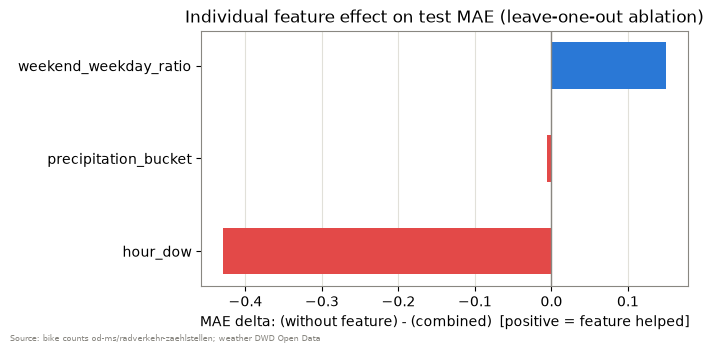

In [13]:
import matplotlib.pyplot as plt

# Same fixed palette as notebook 07 (not matplotlib's default rainbow
# cycle): blue = "helped" (removing it made MAE worse), red = "did not
# help" (removing it left MAE unchanged or improved it), muted = axis/
# reference lines.
COLOR_BLUE = "#2a78d6"
COLOR_RED = "#e34948"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
    }
)

plot_df = ablation_df.sort_values("mae_delta")
colors = np.where(plot_df["mae_delta"] >= 0, COLOR_BLUE, COLOR_RED)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(plot_df["feature"], plot_df["mae_delta"], color=colors, height=0.5)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)
ax.set_xlabel("MAE delta: (without feature) - (combined)  [positive = feature helped]")
ax.set_title("Individual feature effect on test MAE (leave-one-out ablation)")
ax.grid(axis="y", visible=False)
fig.text(
    0.01,
    0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=6,
    color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

## Summary

- **Leakage guard implemented and verified**: `weekend_weekday_ratio` was
  computed via `compute_weekend_weekday_ratio(train_labeled)` -
  `train_labeled` only, strictly before the chronological cutoff
  (`2026-05-11 04:45:00`) - then broadcast onto both train and test rows
  via `add_weekend_weekday_ratio_feature`. `test_df`/`full_df` were never
  passed into the ratio computation. (See `tests/test_feature_followups.py::
  test_compute_and_broadcast_ratio_train_only_guards_against_leakage` for a
  synthetic end-to-end regression test of this specific guard.)

- **Combined effect (all three features added): a small net regression,
  not an improvement.** MAE 27.616 / RMSE 54.100, vs. notebook 14's
  27.343 / 54.130 - MAE is **worse by +0.27 (+1.0%)**, RMSE is
  marginally better by -0.03 (-0.06%, within noise). Reporting this
  honestly rather than stopping at "no clear win": the combined package,
  as specified, is not a good change to adopt as-is.

- **Individual effect sizes** (leave-one-out ablation, `combined` vs.
  each `minus_*` variant; permutation importance from the `combined`
  model, MAE-degradation scale, `n_repeats=5` on a 20K-row sample):

  | Feature | MAE delta (removing it) | RMSE delta (removing it) | Permutation importance | Verdict |
  |---|---|---|---|---|
  | `precipitation_bucket` | -0.006 | -0.009 | 0.006 (17th of 20, near-bottom) | **No effect**, same conclusion as the distance-feature test in notebook 13. Trees already capture the threshold effect via splits on the raw continuous `weather_precipitation_mm` (still in the feature set); the bucketed category adds essentially nothing on top. |
  | `hour_dow` | **-0.429** | **-0.192** | 2.79 (6th of 20 - genuinely used) | **Net harmful.** The model *does* use it (meaningful permutation importance, more than `station_id` or any single weather feature) but using it makes held-out accuracy *worse*, not better - removing it alone (`minus_hour_dow`) drops MAE to 27.187 / RMSE to 53.908, which **beats notebook 14's baseline outright**. `hour`/`day_of_week` already let the trees approximate this interaction across splits; making it an explicit 168-category column appears to let the forest fit an interaction pattern that doesn't generalize to the 8-week holdout as well as the two separate columns already did. |
  | `weekend_weekday_ratio` | **+0.150** | **+0.217** | 1.53 (7th of 20) | **Genuine, modest help.** Removing it makes both MAE and RMSE worse - the only one of the three with a real, in the intended direction, improvement. |

- **The actionable finding is narrower than "add all three"**: the
  *best* configuration tried here is `minus_hour_dow` (base feature set +
  `weekend_weekday_ratio` + `precipitation_bucket`, no `hour_dow`) at
  **MAE 27.187 / RMSE 53.908** - an improvement over notebook 14's
  current best (27.343 / 54.130) of about **0.57% MAE / 0.41% RMSE**.
  `precipitation_bucket` can be included or dropped with no measurable
  difference either way (its own ablation delta is noise-level); the one
  feature that must **not** be adopted is `hour_dow`.

- **Per-station**: `combined` mostly regresses slightly vs. notebook
  14's RF (19 of 23 stations, -0.08% to -5.06%), with a handful of small
  improvements (`300038855` +3.25%, `100053305` +3.04%, `300037936`
  +2.84%, `100034982` +0.46%). Both previously-flagged stations still
  beat the seasonal-naive baseline overall (`300037405` +10.5%,
  `300038855` +9.9%), but `300037405` specifically regresses vs.
  notebook 14's RF (-5.06%) under `combined` - consistent with
  `hour_dow` actively hurting accuracy, since that station's own
  ablation would be expected to follow the same pattern as the overall
  numbers. As per notebook 14's own carried-forward caveat (cross-
  checked against notebook 12): `300038855`'s test window is ~90%
  gap-or-zero from a sensor outage, so its per-station score here should
  not be read as a validated real-world improvement.

- **Conclusion**: two of notebook 07's three deferred findings turn out
  to be non-improvements once actually tested against this random
  forest - `precipitation_bucket` is redundant (null result, same
  pattern as notebook 13's distance feature), and `hour_dow` is actively
  counterproductive despite the model assigning it real importance. Only
  `weekend_weekday_ratio` earns its place as a feature. Recommendation:
  adopt `weekend_weekday_ratio` (with its train-period-only leakage
  guard) as a permanent feature in any future random-forest notebook;
  do not adopt `hour_dow`; `precipitation_bucket` is optional/inert.
  This is a good example of why the project's ablation-not-assumption
  convention matters: naively bundling all three "plausible" features
  together would have shipped a net regression and hidden a genuine
  small win underneath it.